In [ ]:
import pandas as pd
from pipeline import create_X_y_df
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df_full = pd.read_parquet("../../../data/churn-prediction-25-26/train.parquet")

In [3]:
df = df_full.copy()

In [4]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [5]:
df_cancelled = df_X.merge(df_y, on = "userId")

In [6]:
df_cancelled = df_cancelled[df_cancelled["Cancellation Confirmation"] == 1]

In [7]:
df_not_cancelled = df_X.merge(df_y, on = "userId")

In [8]:
df_not_cancelled = df_not_cancelled[df_not_cancelled["Cancellation Confirmation"] == 0]

In [9]:
df_h = df_not_cancelled.copy()

In [10]:
df_h["date"] = pd.to_datetime(df_h["time"])

In [11]:
df_h["week"] = df_h["date"].dt.isocalendar().week

In [12]:
df_h = df_h.groupby(["userId", "week"])["length"].sum().reset_index()

In [13]:
df_a = df_cancelled.copy()

In [14]:
df_a["date"] = pd.to_datetime(df_a["time"])

In [15]:
df_a["week"] = df_a["date"].dt.isocalendar().week

In [16]:
df_b = df_a.groupby(["userId", "week"])["length"].sum().reset_index()

In [17]:
df_b

,userId,week,length
0,1000280,40,75744.22604
1,1000280,41,8911.65807
2,1000280,42,75557.01410
3,1000280,43,15590.47861
4,1000280,44,45025.92664
...,...,...,...
3133,1997399,44,89766.20652
3134,1998830,41,7438.30153
3135,1998830,42,0.00000
3136,1998830,43,20125.92664


<Axes: xlabel='week', ylabel='length'>

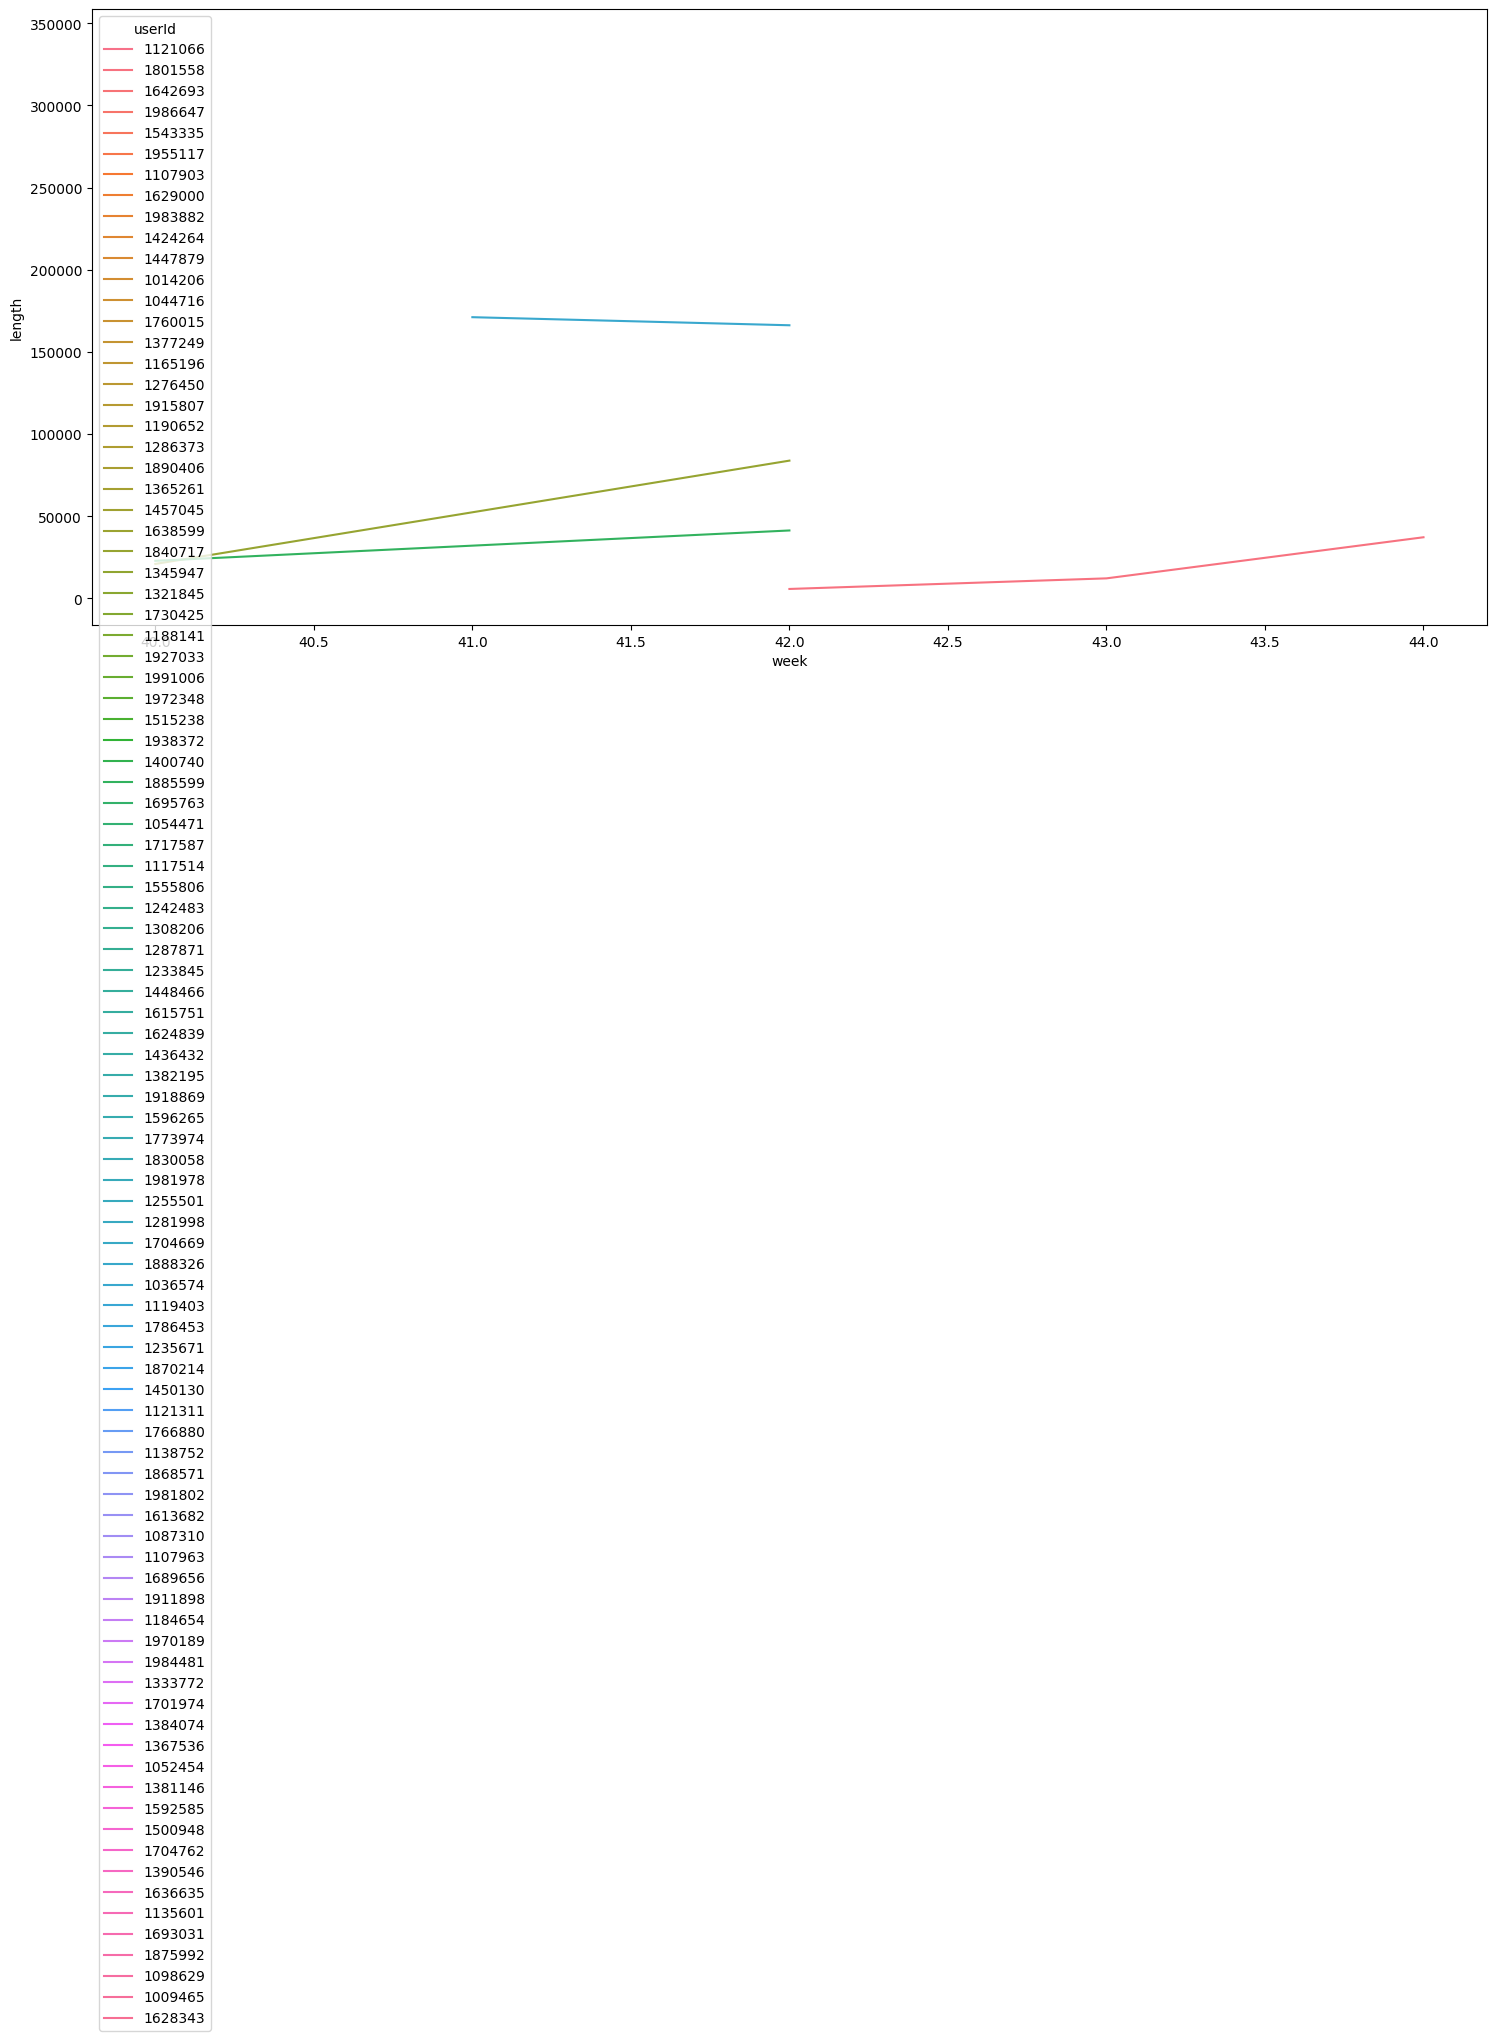

In [18]:
plt.figure(figsize=(18,8))
#sns.lineplot(df_b, x = "week", y = "length")

sns.lineplot(df_b.sample(100), x = "week", y = "length", hue="userId", estimator=None)

<Figure size 1800x800 with 0 Axes>

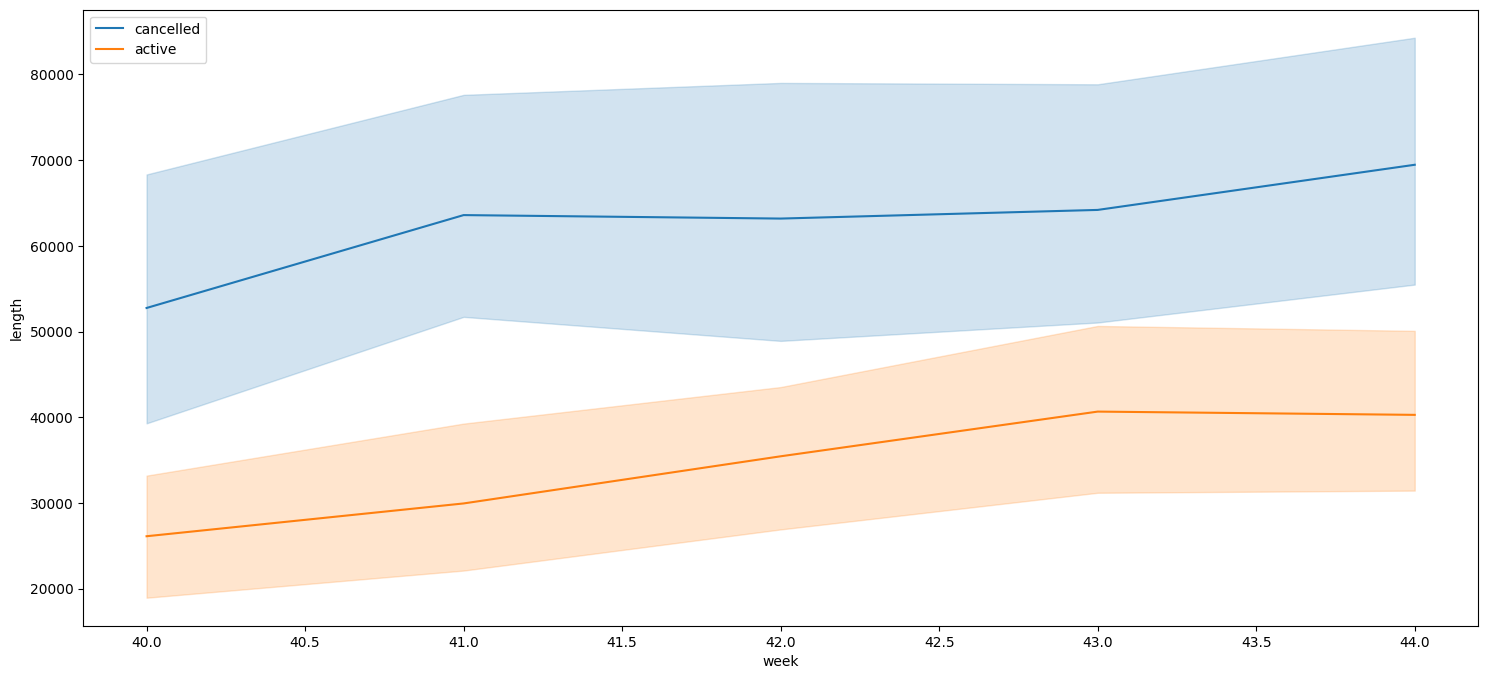

In [19]:
n_users = 100
rng = 4

users_cancelled = df_b["userId"].dropna().unique()
users_active = df_h["userId"].dropna().unique()

picked_cancelled = pd.Series(users_cancelled).sample(n=min(n_users, len(users_cancelled)), random_state=rng)
picked_active = pd.Series(users_active).sample(n=min(n_users, len(users_cancelled)), random_state=rng)

df_100_cancelled = df_b[df_b["userId"].isin(picked_cancelled)].sort_values(["userId", "week"])

df_100_active = df_h[df_h["userId"].isin(picked_active)].sort_values(["userId", "week"])

plt.figure(figsize=(18, 8))
#sns.lineplot(
#    data=df_100,
#    x="week",
#    y="length",
#    hue="userId",
#    estimator=None,   # don't average across duplicates
#    legend=False      # usually too many entries; remove or set to 'brief'
#)


dcb = df_100_cancelled.groupby(["userId","week"], as_index=False)["length"].mean()
dca = df_100_active.groupby(["userId","week"], as_index=False)["length"].mean()

plt.figure(figsize=(18,8))
sns.lineplot(data=dcb, x="week", y="length", label="cancelled")
sns.lineplot(data=dca, x="week", y="length", label="active")
plt.show()

<Figure size 1800x800 with 0 Axes>

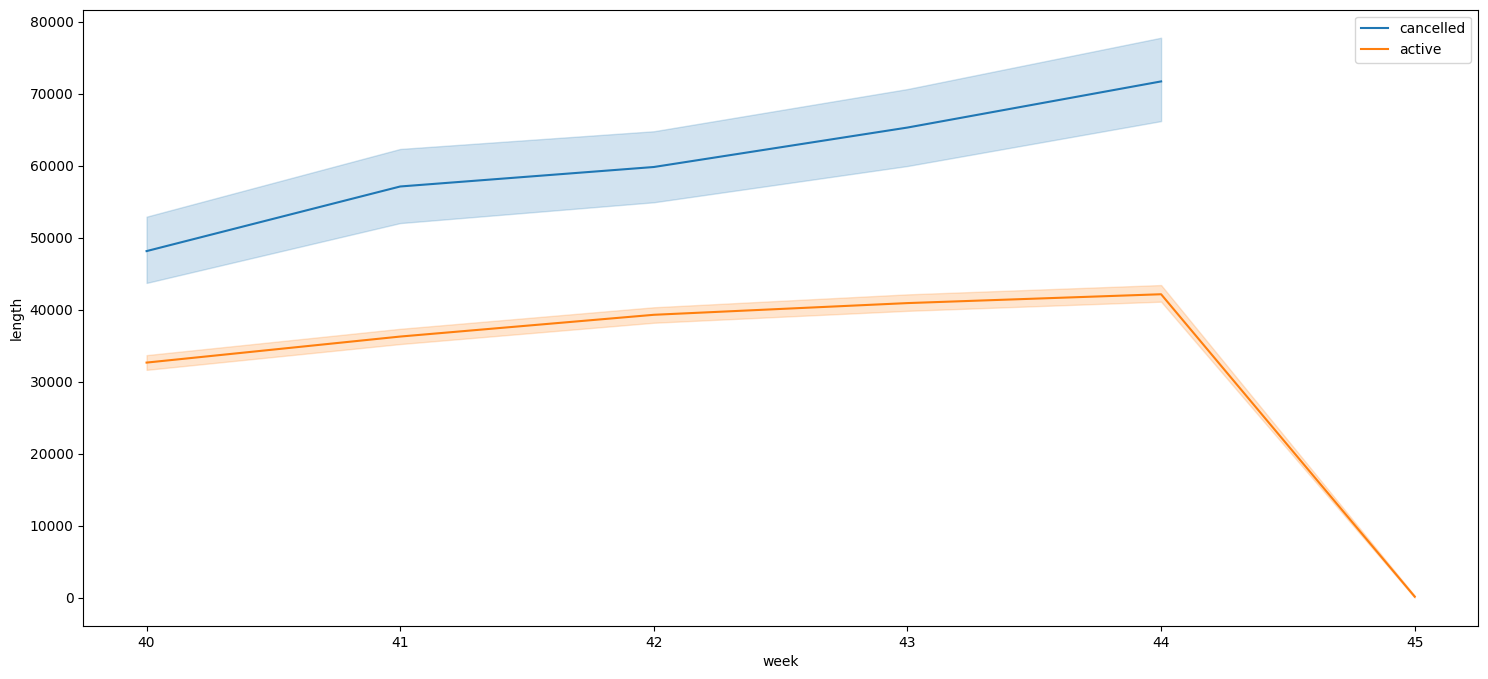

In [20]:
n_users = 10000
rng = 4

users_cancelled = df_b["userId"].dropna().unique()
users_active = df_h["userId"].dropna().unique()

picked_cancelled = pd.Series(users_cancelled).sample(n=min(n_users, len(users_cancelled)), random_state=rng)
picked_active = pd.Series(users_active).sample(n=min(n_users, len(users_active)), random_state=rng)

df_100_cancelled = df_b[df_b["userId"].isin(picked_cancelled)].sort_values(["userId", "week"])

df_100_active = df_h[df_h["userId"].isin(picked_active)].sort_values(["userId", "week"])

plt.figure(figsize=(18, 8))

dcb = df_100_cancelled.groupby(["userId","week"], as_index=False)["length"].mean()
dca = df_100_active.groupby(["userId","week"], as_index=False)["length"].mean()

plt.figure(figsize=(18,8))
sns.lineplot(data=dcb, x="week", y="length", label="cancelled")
sns.lineplot(data=dca, x="week", y="length", label="active")
plt.show()

In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

In [22]:
df_X.head()

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration,date
1,200,F,Vianney,paid,Miller,1563081,1538352002000,Logged In,NextSong,20836,"San Francisco-Oakland-Hayward, CA",9,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,238.39302,MiÃÂ©ntele,Los Bunkers,2018-10-01 00:00:02,2018-09-21 03:25:18,2018-10-01 00:00:02
448,200,F,Vianney,paid,Miller,1563081,1538352240000,Logged In,NextSong,20836,"San Francisco-Oakland-Hayward, CA",10,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,263.88853,Animal,Miike Snow,2018-10-01 00:04:00,2018-09-21 03:25:18,2018-10-01 00:04:00
945,200,F,Vianney,paid,Miller,1563081,1538352503000,Logged In,NextSong,20836,"San Francisco-Oakland-Hayward, CA",11,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,273.47546,Mi Corazon Continuara,Lorena,2018-10-01 00:08:23,2018-09-21 03:25:18,2018-10-01 00:08:23
1509,200,F,Vianney,paid,Miller,1563081,1538352776000,Logged In,NextSong,20836,"San Francisco-Oakland-Hayward, CA",12,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,284.86485,The Real Slim Shady,Eminem,2018-10-01 00:12:56,2018-09-21 03:25:18,2018-10-01 00:12:56
2066,200,F,Vianney,paid,Miller,1563081,1538353060000,Logged In,NextSong,20836,"San Francisco-Oakland-Hayward, CA",13,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,304.45669,The People In My Peephole,Claw Hammer,2018-10-01 00:17:40,2018-09-21 03:25:18,2018-10-01 00:17:40


In [51]:
df_x = df_X.copy()

In [52]:
df_x["time"] = pd.to_datetime(df_x["time"])

In [53]:
df_x["week"] = df["time"].dt.isocalendar().week

In [54]:
df_x = df_x.groupby(["userId", "week"])["length"].sum().reset_index()

In [55]:
df_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53266 entries, 0 to 53265
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   userId  53266 non-null  object 
 1   week    53266 non-null  UInt32 
 2   length  53266 non-null  float64
dtypes: UInt32(1), float64(1), object(1)
memory usage: 1.1+ MB


In [56]:
df_x = df_x[["userId", "week", "length"]]

In [57]:
df_x = df_x.pivot(index="userId", columns="week", values="length")

In [58]:
df_x = df_x.fillna(0.0)

In [59]:
df_x = df_x.merge(df_y, on="userId")

In [60]:
df_x

,userId,40,41,42,43,44,45,Cancellation Confirmation
0,1000035,625.63129,16115.48490,89499.13327,63572.98773,13150.09515,0.0,0
1,1000103,9769.04682,0.00000,0.00000,2801.60064,0.00000,0.0,0
2,1000164,771.26440,30298.11806,51982.40415,8801.42130,0.00000,0.0,0
3,1000168,19520.58929,38769.58894,27861.13357,0.00000,0.00000,0.0,0
4,1000182,0.00000,0.00000,16550.18445,10782.46539,42263.48353,0.0,0
...,...,...,...,...,...,...,...,...
15428,1999241,7715.92952,0.00000,9459.23639,32320.64320,10639.88819,0.0,0
15429,1999382,8425.23283,0.00000,0.00000,0.00000,0.00000,0.0,0
15430,1999781,87995.23923,38239.01859,13948.36923,105173.04538,277033.95760,0.0,0
15431,1999848,25892.78729,17311.26294,18592.22630,9337.92464,33725.82103,0.0,0


<Axes: xlabel='Cancellation Confirmation', ylabel='44'>

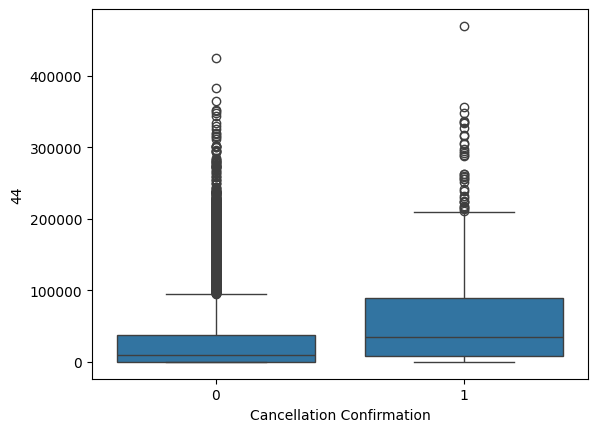

In [61]:
sns.boxplot(df_x, x = "Cancellation Confirmation", y = 44)

In [62]:
clf = HistGradientBoostingClassifier()

In [63]:
df_x.rename({
    40: "40",
    41: "41",
    42: "42",
    43: "43",
    44: "44",
    45: "45"
}, inplace=True)

In [64]:
df_x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15433 entries, 0 to 15432
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   userId                     15433 non-null  object 
 1   40                         15433 non-null  float64
 2   41                         15433 non-null  float64
 3   42                         15433 non-null  float64
 4   43                         15433 non-null  float64
 5   44                         15433 non-null  float64
 6   45                         15433 non-null  float64
 7   Cancellation Confirmation  15433 non-null  int8   
dtypes: float64(6), int8(1), object(1)
memory usage: 979.6+ KB


In [67]:
df_x.columns = ['userId', "40", "41", "42", "43", "44", "45", 'Cancellation Confirmation']

In [68]:
X_columns = ["40", "41", "42", "43", "44", "45"]
y_columns = "Cancellation Confirmation"

In [70]:
X = df_x[X_columns]
y = df_x[y_columns]

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [73]:
clf.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [74]:
y_pred = clf.predict(X_test)

In [75]:
from sklearn.metrics import confusion_matrix

In [77]:
confusion_matrix(y_test, y_pred)

array([[3685,    0],
       [ 174,    0]])

In [ ]:
confusion_matrix(y_test, y_pred)

array([[3685,    0],
       [ 174,    0]])